![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [52]:
import warnings
warnings.filterwarnings('ignore')

In [53]:
# Importación librerías
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [ ]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [55]:
df.shape

(541462, 3)

<Axes: >

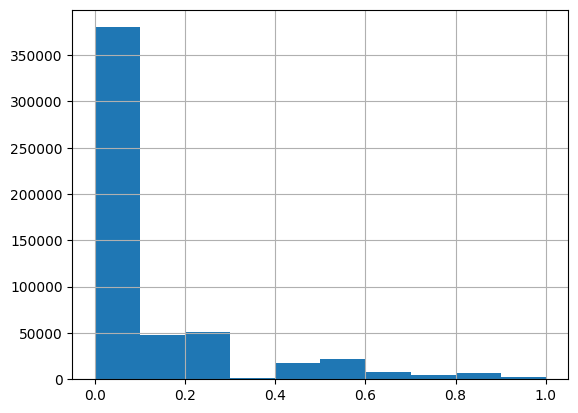

In [56]:
# Impresión histograma de variable de interés (y)
df.target.hist()

In [57]:
# Separación de variable de interés (y)
y = df.target
y.describe()

count    541462.000000
mean          0.102991
std           0.196979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: target, dtype: float64

In [58]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [59]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [60]:
# Celda 1

# Se transforman los datos usando CountVectorizer
vectorizer = CountVectorizer(lowercase=True, stop_words='english',max_features=10000)
X_train_v = vectorizer.fit_transform(X_train)
X_test_v = vectorizer.transform(X_test)
print('Cantidad de tokens generados:', len(vectorizer.get_feature_names_out()))

Cantidad de tokens generados: 10000


In [61]:
from sklearn.linear_model import Ridge
reg = Ridge()
reg.fit(X_train_v, y_train)
y_pred = reg.predict(X_test_v)
mse_cv= mean_squared_error(y_test, y_pred)

print("MSE: ", mse_cv)

MSE:  0.023511619043040957


In [62]:
reg = RandomForestRegressor(n_estimators=50, max_depth=10, max_features='sqrt', n_jobs=-1, random_state=42)
reg.fit(X_train_v, y_train)
y_pred=reg.predict(X_test_v)
mse_cv= mean_squared_error(y_test, y_pred)

print("MSE: ", mse_cv)

MSE:  0.0356421529629509


In [63]:
from xgboost import XGBRegressor
reg= XGBRegressor()
reg.fit(X_train_v, y_train)
y_pred= reg.predict(X_test_v)
mse_cv= mean_squared_error(y_test, y_pred)

print("MSE: ", mse_cv)

MSE:  0.022475765153425555


## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [64]:
# Celda 2
vectorizer=CountVectorizer(lowercase=True, stop_words='english', ngram_range=(3, 3),max_features=10000)

X_train_v = vectorizer.fit_transform(X_train)
X_test_v = vectorizer.transform(X_test)
print('Cantidad de tokens generados:', len(vectorizer.get_feature_names_out()))

Cantidad de tokens generados: 10000


In [65]:
reg = Ridge()
reg.fit(X_train_v, y_train)
y_pred = reg.predict(X_test_v)
mse_tri= mean_squared_error(y_test, y_pred)

print("MSE: ", mse_tri)

MSE:  0.039050677771927805


In [66]:
reg = RandomForestRegressor(n_estimators=50, max_depth=10, max_features='sqrt', n_jobs=-1, random_state=42)
reg.fit(X_train_v, y_train)
y_pred=reg.predict(X_test_v)
mse_tri= mean_squared_error(y_test, y_pred)

print("MSE: ", mse_tri)

MSE:  0.03894436291147881


In [67]:
reg= XGBRegressor()
reg.fit(X_train_v, y_train)
y_pred= reg.predict(X_test_v)
mse_tri= mean_squared_error(y_test, y_pred)

print("MSE: ", mse_tri)

MSE:  0.038554272607303035


## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

### Celda 3

Recordemos que CountVectorizer convierte cada pieza de texto en una colección de tokens y construye una matriz donde:
- Cada columna es una palabra (o n-grama).
- Cada fila es una pieza de text (ej. un comentario).
- Cada celda contiene el número de veces que la palabra aparece en dicho texto.


El **TF-IDF (Term Frequency-Inverse Document Frequency)** es una técnica fundamental en el procesamiento de lenguaje natural que permite transformar texto en representaciones numéricas mientras destaca las palabras más relevantes y reduce la importancia de términos comunes. TfidfVectorizer también convierte texto en una matriz numérica, pero en lugar de contar palabras, calcula un puntaje llamado TF-IDF el cual también cuenta el numero de ocurrencias de cada término pero al mismo tiempo "penaliza" aquellos términos que tienen mayores ocurrencias. Esto con el objetivo de reducir el impacto de palabras comunes que aportan poca informacíon como "the", "is", "on", "and".


**Term Frequency (TF)**

La frecuencia del término mide qué tan frecuente aparece una palabra en un documento:

$$
TF(t,d) = \frac{\text{Número de veces que aparece el término t en el documento d}}{\text{Número total de términos en el documento d}}
$$
En notación matemática:

$$
TF(t,d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}
$$

- *f(t,d)* es la frecuencia del término t en el documento d.

- El denominador es la suma de las frecuencias de todos los términos en el documento.


**Inverse Document Frequency (IDF)**

La frecuencia inversa del documento mide qué tan rara es una palabra en toda la colección de documentos:

$$
IDF(t) = \ln\left(\frac{1 + N}{1 + DF(t)}\right) + 1
$$

Donde:
- N es el número total de documentos en la colección.
- DF(t) es el número de documentos que contienen el término t.
- Se suma 1 en el numerador y denominador para evitar divisiones por cero.
- Se suma 1 al final para asegurar que términos que aparecen en todos los documentos no se anulen completamente.


**TF-IDF Score**

El puntaje TF-IDF es el producto de ambas formulaciones:

$$
TFIDF(t,d) = TF(t,d) \times IDF(t)
$$

Por lo que:

- **TF (Term Frecuency)** mide la frecuencia del término (número de veces que aparece una palabra en un documento). Donde TF(t, d) es el número de veces que el término t aparece en el documento d dividido entre la suma de todas las ocurrencias de todos los términos en el documento.

- **IDF (Inverse Document Frequency)** mide la frecuencia inversa del término (qué tan rara es esa palabra en el documento). Donde IDF(t) es uno más el logaritmo natural del cociente de uno más el numero total de documentos N dividido entre uno más el número de documentos en donde aparece el término t.
  
- Una palabra tendrá un valor alto solo si se cumplen las dos condiciones; a saber, que aparece mucho en un documento específico (TF alto) y que es rara en el resto del documento (IDF alto).


**Ventajas de utilziar TF-IDF**

- TFIDFVectorizer reduce automáticamente la importancia de términos que aparecen con mucha frecuencia en todos los documentos (conectores), que generalmente aportan poco valor semántico, dando mayor peso a palabras que son distintivas para ciertos documentos, lo que puede mejorar significativamente el rendimiento en modelos de clasificación de texto, pues,  generalmente mejora el rendimiento de algoritmos de este tipo de modelos al enfatizar características discriminativas.

- Al usar IDF, se normaliza de manera implícita la importancia de cada palabra según su distribución en todo el corpus, lo que ayuda a equilibrar documentos de diferentes longitudes, mejorando la precisión en modelos usados como sistemas de búsqueda, TF-IDF tiende a proporcionar resultados más relevantes al destacar términos distintivos.


**Desventajas de TfidfVectorizer**

- Al usar TfidfVectorizer, existe una carga computacional mayor, pues requiere más cálculos que el conteo de palabras, lo que puede ser significativo para datasets grandes. El cálculo del IDF depende de todo el corpus del documento, lo que dificulta la vectorización incremental de nuevos documentos sin recalcular los valores obtenidos.

- Los valores TF-IDF son más difíciles de interpretar directamente que los conteos de palabras. Ademas al normalizar, se puede perder información sobre la frecuencia absoluta que en algunos casos podría ser relevante.



Para determinar el uso de cada modulo, se debe tener en cuenta en cuenta lo siguiente:

- Usar CountVectorizer cuando:

    * Se necesita una representación simple e intuitiva de frecuencias.
    * Se debe realizar análisis exploratorio inicial y se requieren conteos absolutos.
    * Se trabaja con textos pequeños donde la eficiencia computacional es crucial.

- Usar TfidfVectorizer cuando:

    * Se necesita distinguir términos realmente importantes en cada corpus de los documentos.
    * Se deben usar modelos de clasificación o agrupación de textos
    * Se requiere implementar sistemas de búsqueda o recomendación
    * Se busca reducir el impacto de palabras comunes sin eliminarlas con una lista de stopwords.

La elección entre ambos modulo depende del caso de uso y se pueden probar ambos enfoques para determinar cuál ofrece mejor rendimiento para alguna aplicación particular.

## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [68]:
# Celda 4
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(lowercase=True, stop_words='english',max_features=10000)

X_train_v = vectorizer.fit_transform(X_train)
X_test_v = vectorizer.transform(X_test)

In [69]:
reg = Ridge()
reg.fit(X_train_v, y_train)
y_pred = reg.predict(X_test_v)
mse_tfidf= mean_squared_error(y_test, y_pred)

print("MSE: ", mse_tfidf)

MSE:  0.019167364392845214


In [70]:
reg = RandomForestRegressor(n_estimators=500, max_depth=20, max_features='sqrt', n_jobs=-1, random_state=42)
reg.fit(X_train_v, y_train)
y_pred=reg.predict(X_test_v)
mse_tfidf= mean_squared_error(y_test, y_pred)

print("MSE: ", mse_tfidf)

MSE:  0.03326769294822214


In [71]:
reg= XGBRegressor()
reg.fit(X_train_v, y_train)
y_pred= reg.predict(X_test_v)
mse_tfidf= mean_squared_error(y_test, y_pred)

print("MSE: ", mse_tfidf)

MSE:  0.02082003743547481


## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

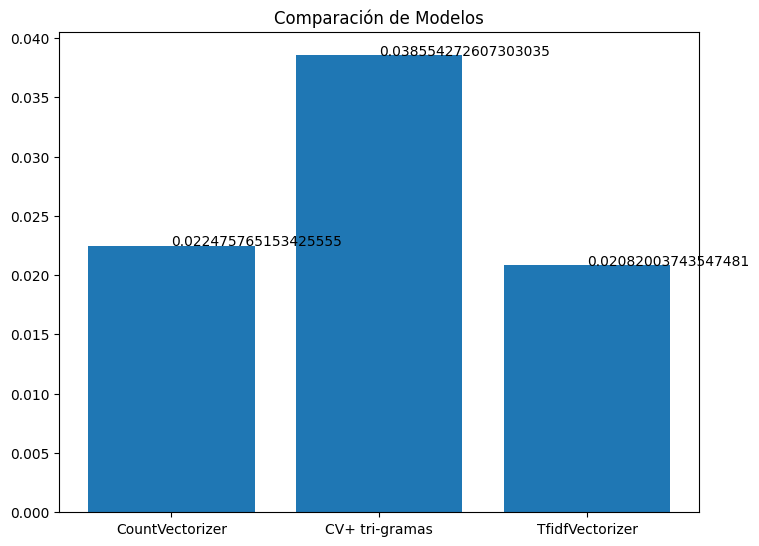

In [72]:
# Celda 5
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_title("Comparación de Modelos")
ejeX = ['CountVectorizer','CV+ tri-gramas','TfidfVectorizer']
ejeY = [mse_cv, mse_tri,mse_tfidf]
ax.bar(ejeX,ejeY)
def addlabels(x,y,plotP):
    for i in range(len(x)):
        plotP.text(i,y[i],y[i])
addlabels(ejeX,ejeY,plt)
plt.show()

## Análisis
---

El modelo con mejor desempeño es aquel que presenta un menor MSE. En el caso analizado, **TF-IDF con  obtuvo el valor más bajo **. Esto se explica porque TF-IDF otorga mayor peso a los n-gramas más frecuentes, penaliza las características raras y descarta conectores muy comunes (“the”, “is”, “on”, “and”). En cambio, **CountVectorizer con trigramas es el de peor desempeño**, ya que el conteo puro no diferencia la relevancia de cada n-grama en el corpus.

Al examinar únicamente CountVectorizer, se obersva que los trigramas reducen el error frente a los bigramas porque capturan un contexto más amplio. Sin embargo, con TF-IDF ocurre lo opuesto, los trigramas empeoran el MSE. En este caso podría argumentarse que el aumento de dimensionalidad y el ruido que generan secuencias de texto muy específicas penalizan la capacidad de generalización del modelo.

TF-IDF introduce dos ajustes clave el Term Frequency (frecuencia local) e Inverse Document Frequency (penaliza términos excesivamente comunes), que ayudan a disminuir el ruido y a realizar patrones menos frecuentes pero más característicos del grado de "toxicidad" de la red social. En cuanto a la selección de n-gramas, los bigramas equilibran contexto y ruido al capturar la mayoría de expresiones agresivas sin fragmentar en exceso el texto. Por su parte, los trigramas amplían el contexto, pero generan muchas columnas escasamente representadas, lo que incrementa la carga computacional y añade ruido estadístico, afectando la estabilidad del modelo. Además, TF-IDF facilita el filtrado de stopwords y conectores al generar n-gramas, controla el tamaño del vocabulario y reduce el ruido. Conservar la distinción entre mayúsculas y minúsculas ayuda al modelo a detectar énfasis o “gritos” propios de comentarios tóxicos.

Por todo lo anterior y en condiciones similares (excluyendo distintas combinaciones de parámetros), TF-IDF con bigramas es la opción óptima, pues ofrece el menor MSE y un buen balance entre contexto y ruido. Si el corpus presenta un contexto muy complejo y se dispone de suficiente capacidad computacional, los trigramas pueden aportar valor,siempre que se aplique el modulo TF-IDF para mitigar su impacto negativo, pero en escenarios donde el coste computacional es crítico, conviene optar por CountVectorizer con bigramas.

---
